In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully')

All libraries imported successfully


In [2]:
DATA_PATH = '../data/crowding_dataset.csv'  

df = pd.read_csv(DATA_PATH)

print(f'Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('─' * 45)
print(df.dtypes)
print('─' * 45)
df.head(5)

Shape         : 50,000 rows × 18 columns
Memory usage  : 10.2 MB

─────────────────────────────────────────────
timestamp             object
hour                   int64
day_of_week            int64
is_weekend             int64
patient_count          int64
avg_ctas             float64
high_acuity_ratio    float64
avg_waiting_time     float64
max_waiting_time     float64
doctors_available    float64
nurses_available     float64
beds_available       float64
arrival_rate         float64
discharge_rate       float64
is_holiday             int64
flu_season             int64
temperature          float64
crowding_level         int64
dtype: object
─────────────────────────────────────────────


,timestamp,hour,day_of_week,is_weekend,patient_count,avg_ctas,high_acuity_ratio,avg_waiting_time,max_waiting_time,doctors_available,nurses_available,beds_available,arrival_rate,discharge_rate,is_holiday,flu_season,temperature,crowding_level
0,2023-01-01 00:00:00,0,7,1,42,3.74,NaN,132.4,249.3,4.0,NaN,22.0,19.5,7.5,1,1,11.5,2
1,2023-01-01 00:30:00,0,7,1,41,3.08,0.297,80.1,152.7,1.0,8.0,30.0,NaN,12.9,1,1,10.0,1
2,2023-01-01 01:00:00,1,7,1,51,3.60,0.183,97.2,213.4,1.0,3.0,24.0,15.1,18.0,1,1,11.9,1
3,2023-01-01 01:30:00,1,7,1,57,3.24,0.352,132.2,297.7,1.0,7.0,22.0,18.5,14.2,1,1,14.6,2
4,2023-01-01 02:00:00,2,7,1,48,3.33,NaN,NaN,198.5,1.0,1.0,29.0,14.6,12.6,1,1,10.0,1


=== crowding_level Distribution ===
  0 – Low       12,671 rows  (25.3%)
  1 – Medium    31,622 rows  (63.2%)
  2 – High       5,707 rows  (11.4%)



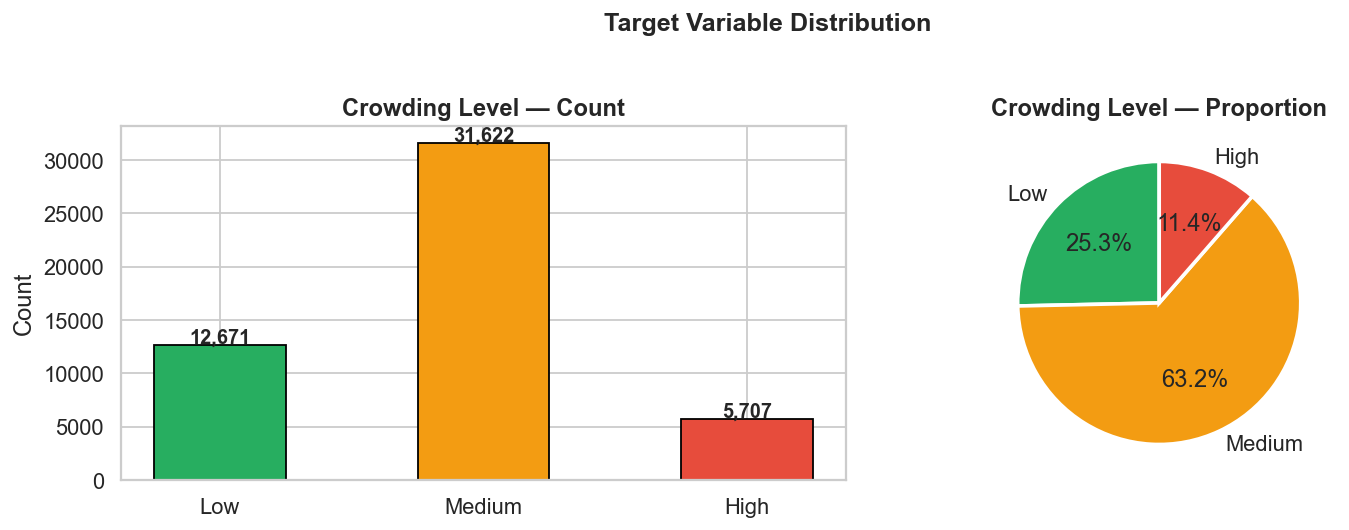

In [3]:
# 3.1  Target Distribution 
CLASS_NAMES = {0: 'Low', 1: 'Medium', 2: 'High'}

counts  = df['crowding_level'].value_counts().sort_index()
pcts    = df['crowding_level'].value_counts(normalize=True).sort_index() * 100

print('=== crowding_level Distribution ===')
for k, (c, p) in enumerate(zip(counts, pcts)):
    print(f'  {k} – {CLASS_NAMES[k]:8s}  {c:6,} rows  ({p:.1f}%)')
print()

COLORS = ['#27ae60', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(CLASS_NAMES.values(), counts.values, color=COLORS, edgecolor='black', width=0.5)
axes[0].set_title('Crowding Level — Count', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=CLASS_NAMES.values(), colors=COLORS,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Crowding Level — Proportion', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

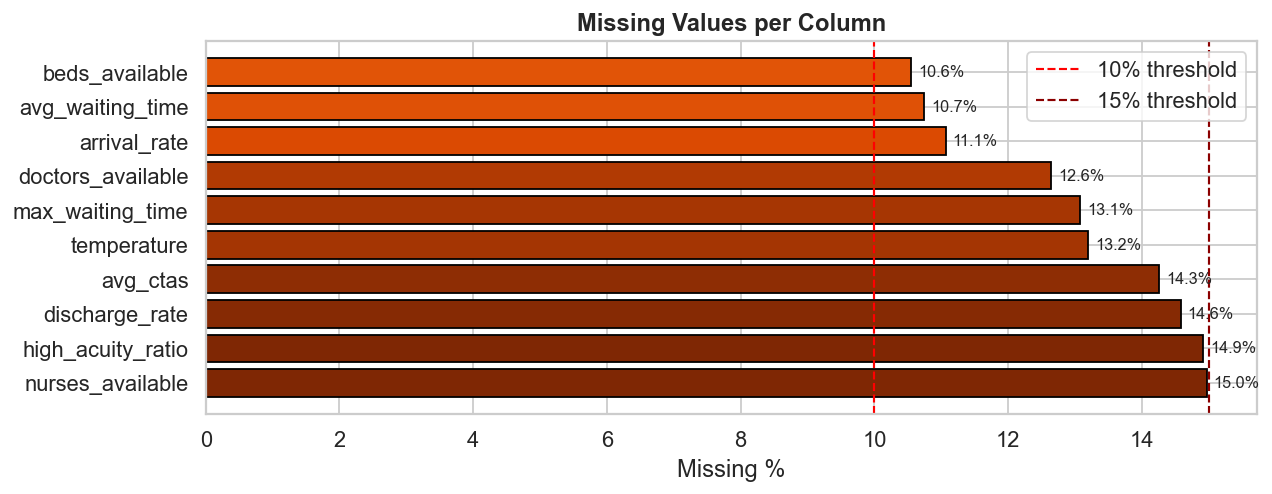

Total missing cells : 65,015 / 900,000  (7.2%)


In [4]:
# 3.2  Missing Values Heatmap 
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(null_pct.index, null_pct.values,
               color=plt.cm.Oranges(null_pct.values / null_pct.max()),
               edgecolor='black')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column', fontweight='bold')
ax.axvline(10, color='red', linestyle='--', linewidth=1.2, label='10% threshold')
ax.axvline(15, color='darkred', linestyle='--', linewidth=1.2, label='15% threshold')
for bar, val in zip(bars, null_pct.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

total_missing = df.isnull().sum().sum()
total_cells   = df.shape[0] * df.shape[1]
print(f'Total missing cells : {total_missing:,} / {total_cells:,}  ({total_missing/total_cells*100:.1f}%)')

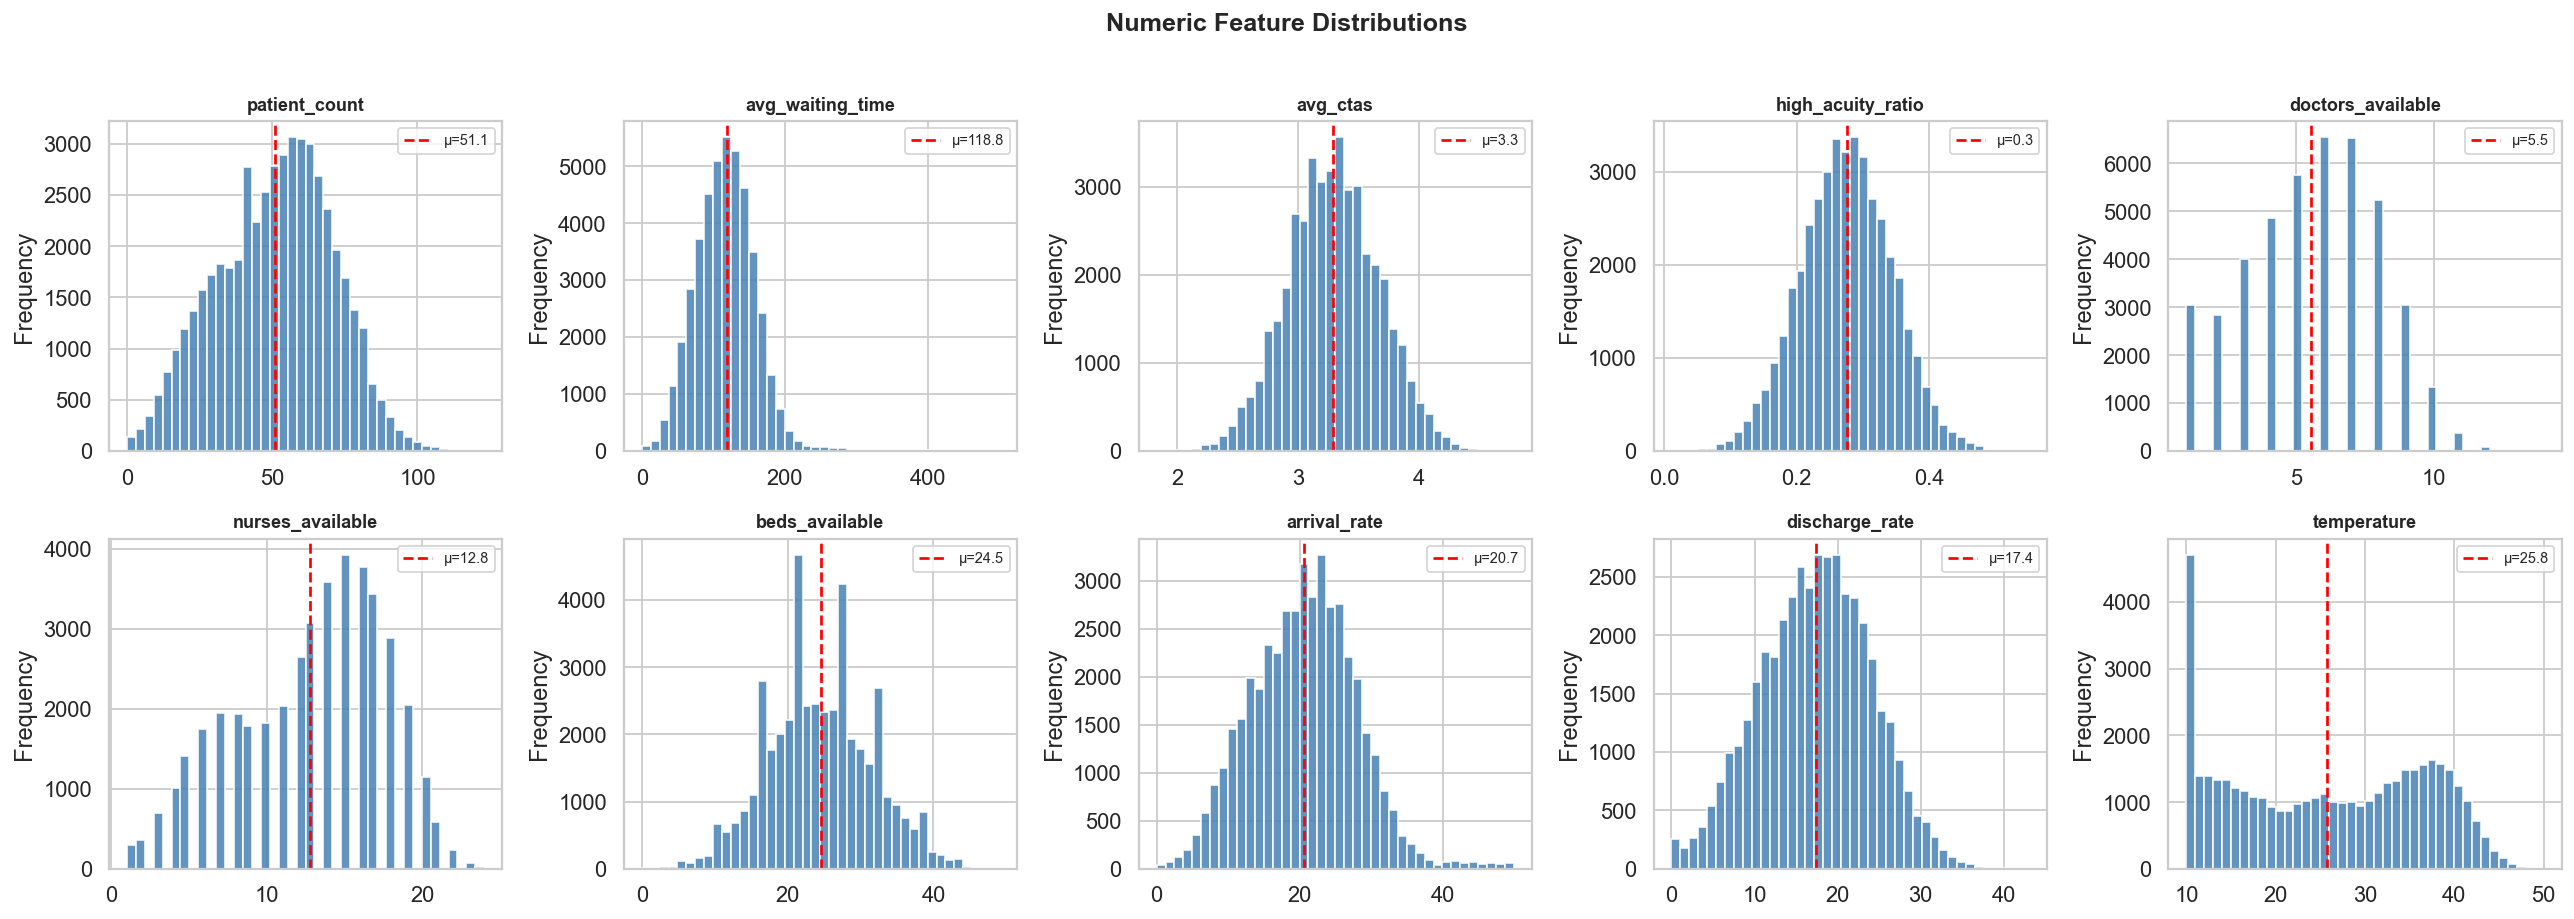

In [5]:
# 3.3  Numeric Feature Distributions 
num_cols = ['patient_count', 'avg_waiting_time', 'avg_ctas',
            'high_acuity_ratio', 'doctors_available',
            'nurses_available', 'beds_available',
            'arrival_rate', 'discharge_rate', 'temperature']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    mu, sd = data.mean(), data.std()
    axes[i].axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'μ={mu:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

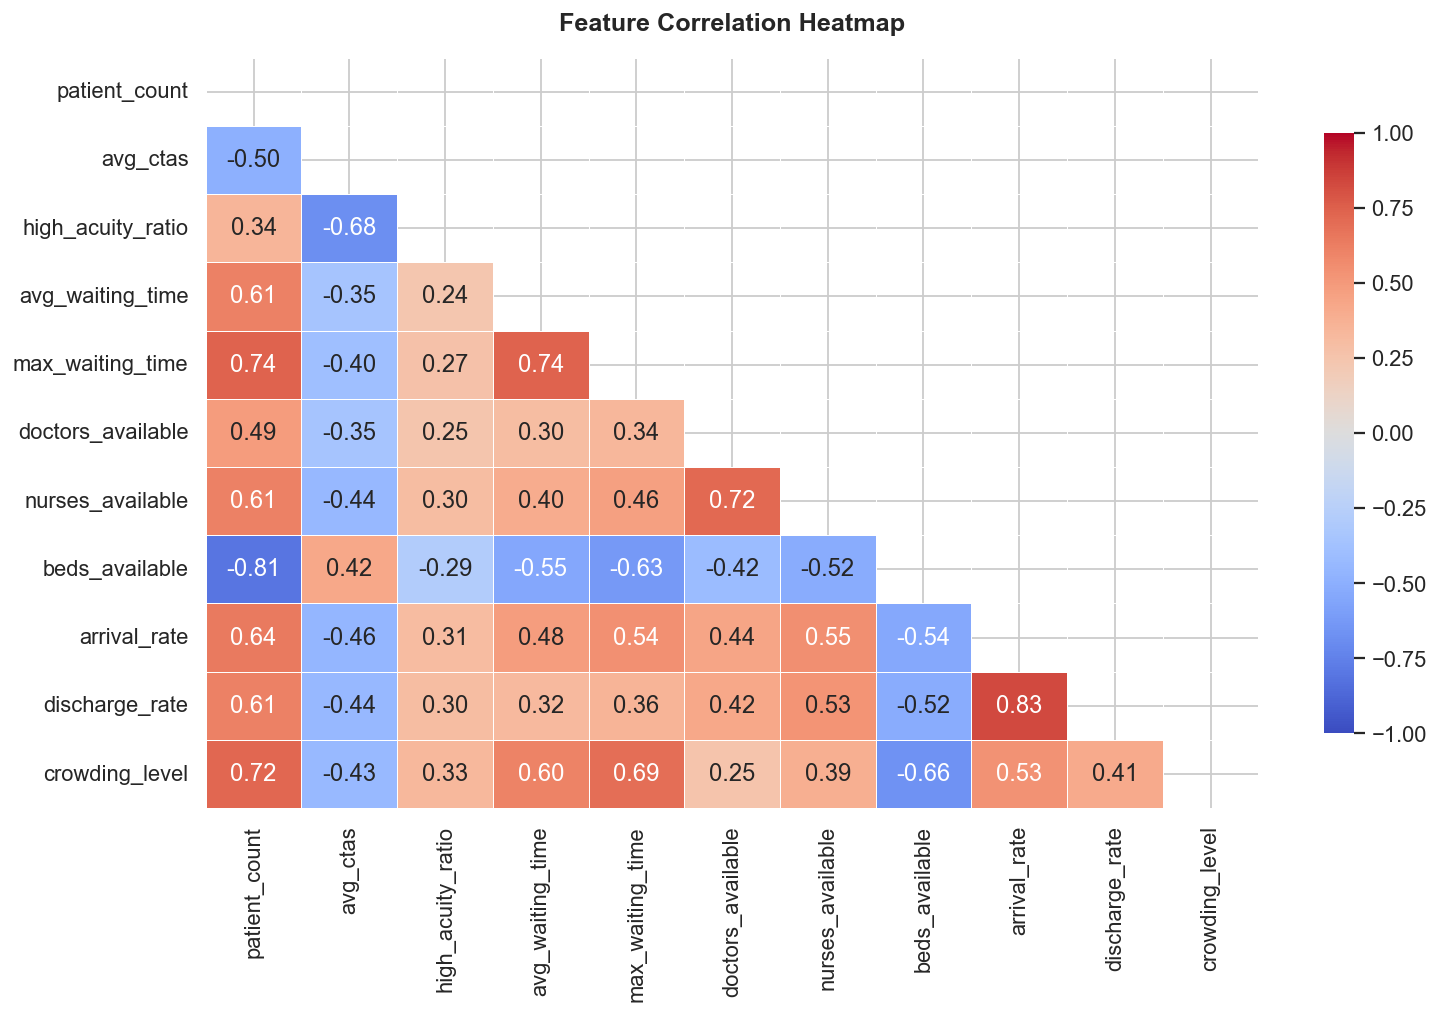

In [6]:
# 3.4  Correlation Heatmap 
corr_cols = ['patient_count', 'avg_ctas', 'high_acuity_ratio',
             'avg_waiting_time', 'max_waiting_time',
             'doctors_available', 'nurses_available', 'beds_available',
             'arrival_rate', 'discharge_rate', 'crowding_level']

corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

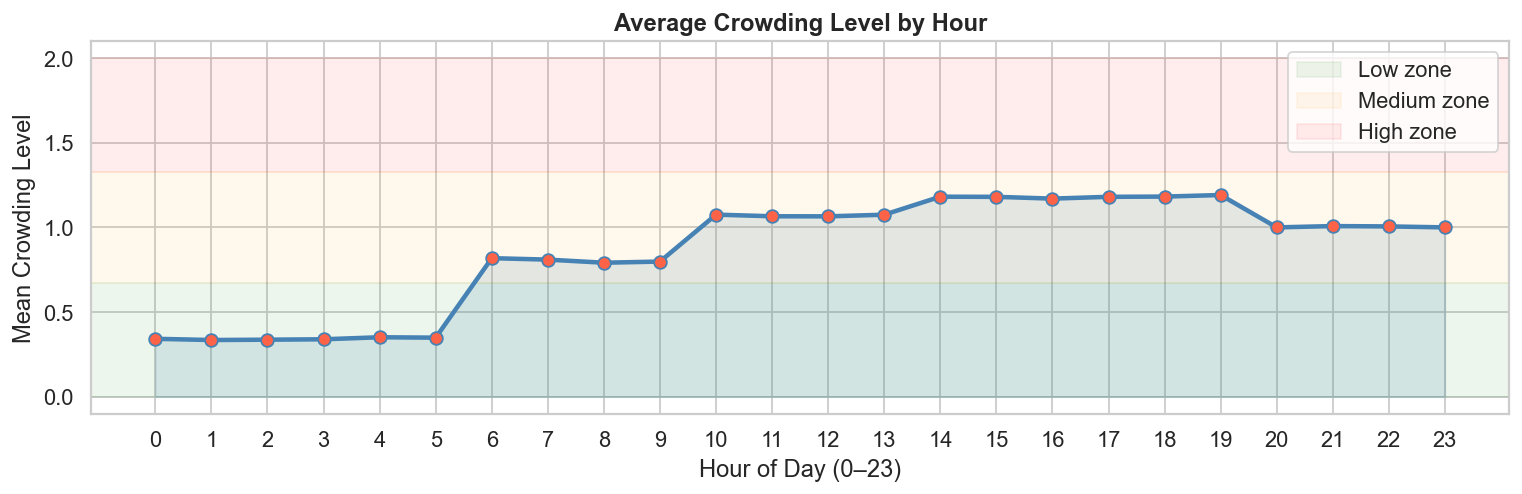

In [7]:
# 3.5  Crowding by Hour of Day 
hourly = df.groupby('hour')['crowding_level'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly.index, hourly.values, marker='o', linewidth=2.5,
        color='steelblue', markerfacecolor='tomato', markersize=7)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='steelblue')
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('Mean Crowding Level')
ax.set_title('Average Crowding Level by Hour', fontweight='bold')
ax.set_xticks(range(0, 24))
ax.axhspan(0, 0.67,  alpha=0.07, color='green', label='Low zone')
ax.axhspan(0.67, 1.33, alpha=0.07, color='orange', label='Medium zone')
ax.axhspan(1.33, 2,   alpha=0.07, color='red',   label='High zone')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
print(f'Shape before cleaning: {df.shape}')

# Drop timestamp (not used as raw feature) 
df = df.drop(columns=['timestamp'])
print('→ Dropped: timestamp')

# Drop rows where target is null 
df = df.dropna(subset=['crowding_level'])
print(f'→ After dropping null targets : {df.shape}')

# Drop duplicate rows 
before = len(df)
df = df.drop_duplicates()
print(f'→ Duplicates removed          : {before - len(df)}')


df['flow_pressure'] = df['arrival_rate'] - df['discharge_rate']

df['bed_pressure'] = df['patient_count'] / (df['beds_available'] + 1)

df['staff_burden'] = df['patient_count'] / (df['doctors_available'] + 1)

# Additional Feature Engineering
df['staff_burden_ratio'] = df['patient_count'] / (
    df['doctors_available'] + df['nurses_available'] + 1
)

df['wait_pressure'] = df['avg_waiting_time'] * df['bed_pressure']

df['acuity_load'] = df['patient_count'] * df['high_acuity_ratio']

print()
print('3 engineered features added:')
print('   → flow_pressure  = arrival_rate − discharge_rate')
print('   → bed_pressure   = patient_count / (beds_available + 1)')
print('   → staff_burden   = patient_count / (doctors_available + 1)')
print()
print(f'Final shape: {df.shape}')

Shape before cleaning: (50000, 18)
→ Dropped: timestamp
→ After dropping null targets : (50000, 17)
→ Duplicates removed          : 0

3 engineered features added:
   → flow_pressure  = arrival_rate − discharge_rate
   → bed_pressure   = patient_count / (beds_available + 1)
   → staff_burden   = patient_count / (doctors_available + 1)

Final shape: (50000, 23)


In [9]:
# Impute missing values with column median
FEATURE_COLS = [c for c in df.columns if c != 'crowding_level']

medians = df[FEATURE_COLS].median()
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(medians)

remaining_nulls = df.isnull().sum().sum()
print(f'Missing values after imputation: {remaining_nulls}')
print(' All nulls filled with column medians')

# Target already numeric (0 / 1 / 2) 
#  crowding_level: 0 = Low, 1 = Medium, 2 = High
print()
print('Target mapping (already encoded):')
for k, v in {0: 'Low', 1: 'Medium', 2: 'High'}.items():
    print(f'  {k}  →  {v}')

Missing values after imputation: 0
 All nulls filled with column medians

Target mapping (already encoded):
  0  →  Low
  1  →  Medium
  2  →  High


In [10]:
X = df.drop(columns=['crowding_level'])
y = df['crowding_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # ← keeps class ratio equal in both splits
)

print(f'Total samples  : {len(df):,}')
print(f'Train set      : {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set       : {len(X_test):,}  ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Class distribution in splits:')
print(f'  {"Class":<10} {"Train":>8} {"Test":>8}')
for cls in sorted(y.unique()):
    name = CLASS_NAMES[cls]
    tr = (y_train == cls).sum()
    te = (y_test  == cls).sum()
    print(f'  {name:<10} {tr:>8,} {te:>8,}')

print()
print('Stratified split done — class ratios preserved')

Total samples  : 50,000
Train set      : 40,000  (80%)
Test set       : 10,000  (20%)

Class distribution in splits:
  Class         Train     Test
  Low          10,137    2,534
  Medium       25,297    6,325
  High          4,566    1,141

Stratified split done — class ratios preserved


In [11]:
# Hyperparameters (selected for balance & generalization) 
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Training model...')
rf_model.fit(X_train, y_train)
print(' Model trained successfully!')
print()
print(f'Number of trees      : {rf_model.n_estimators}')
print(f'Features per tree    : {rf_model.max_features}')
print(f'Number of features   : {X_train.shape[1]}')

Training model...
 Model trained successfully!

Number of trees      : 300
Features per tree    : sqrt
Number of features   : 22


In [12]:
y_pred       = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)
y_proba      = rf_model.predict_proba(X_test)

# Core Metrics
train_acc      = accuracy_score(y_train, y_pred_train)
test_acc       = accuracy_score(y_test, y_pred)
bal_acc        = balanced_accuracy_score(y_test, y_pred)
macro_f1       = f1_score(y_test, y_pred, average='macro')
weighted_f1    = f1_score(y_test, y_pred, average='weighted')
macro_prec     = precision_score(y_test, y_pred, average='macro')
macro_recall   = recall_score(y_test, y_pred, average='macro')
gap            = train_acc - test_acc

# ROC-AUC (One-vs-Rest multiclass) 
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_auc    = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')

print('            MODEL PERFORMANCE SUMMARY')
print(f'  Train Accuracy        : {train_acc*100:>7.2f}%')
print(f'  Test  Accuracy        : {test_acc*100:>7.2f}%')
print(f'  Balanced Accuracy     : {bal_acc*100:>7.2f}%')
print(f'  Macro F1-Score        : {macro_f1:>7.4f}')
print(f'  Weighted F1-Score     : {weighted_f1:>7.4f}')
print(f'  Macro Precision       : {macro_prec:>7.4f}')
print(f'  Macro Recall          : {macro_recall:>7.4f}')
print(f'  ROC-AUC (macro OvR)   : {roc_auc:>7.4f}')
print(f'  Train–Test Gap        : {gap:>7.4f}', end='  →  ')
if gap < 0.05:
    print(' No overfitting')
elif gap < 0.10:
    print(' Slight overfitting — acceptable')
else:
    print(' Overfitting — reduce max_depth or increase min_samples_leaf')

            MODEL PERFORMANCE SUMMARY
  Train Accuracy        :   94.26%
  Test  Accuracy        :   89.99%
  Balanced Accuracy     :   87.69%
  Macro F1-Score        :  0.8739
  Weighted F1-Score     :  0.9001
  Macro Precision       :  0.8712
  Macro Recall          :  0.8769
  ROC-AUC (macro OvR)   :  0.9486
  Train–Test Gap        :  0.0427  →   No overfitting


In [13]:
print('Per-Class Classification Report')
print(classification_report(
    y_test, y_pred,
    target_names=['Low (0)', 'Medium (1)', 'High (2)'],
    digits=4
))

Per-Class Classification Report
              precision    recall  f1-score   support

     Low (0)     0.8734    0.8982    0.8856      2534
  Medium (1)     0.9269    0.9156    0.9212      6325
    High (2)     0.8133    0.8168    0.8150      1141

    accuracy                         0.8999     10000
   macro avg     0.8712    0.8769    0.8739     10000
weighted avg     0.9003    0.8999    0.9001     10000



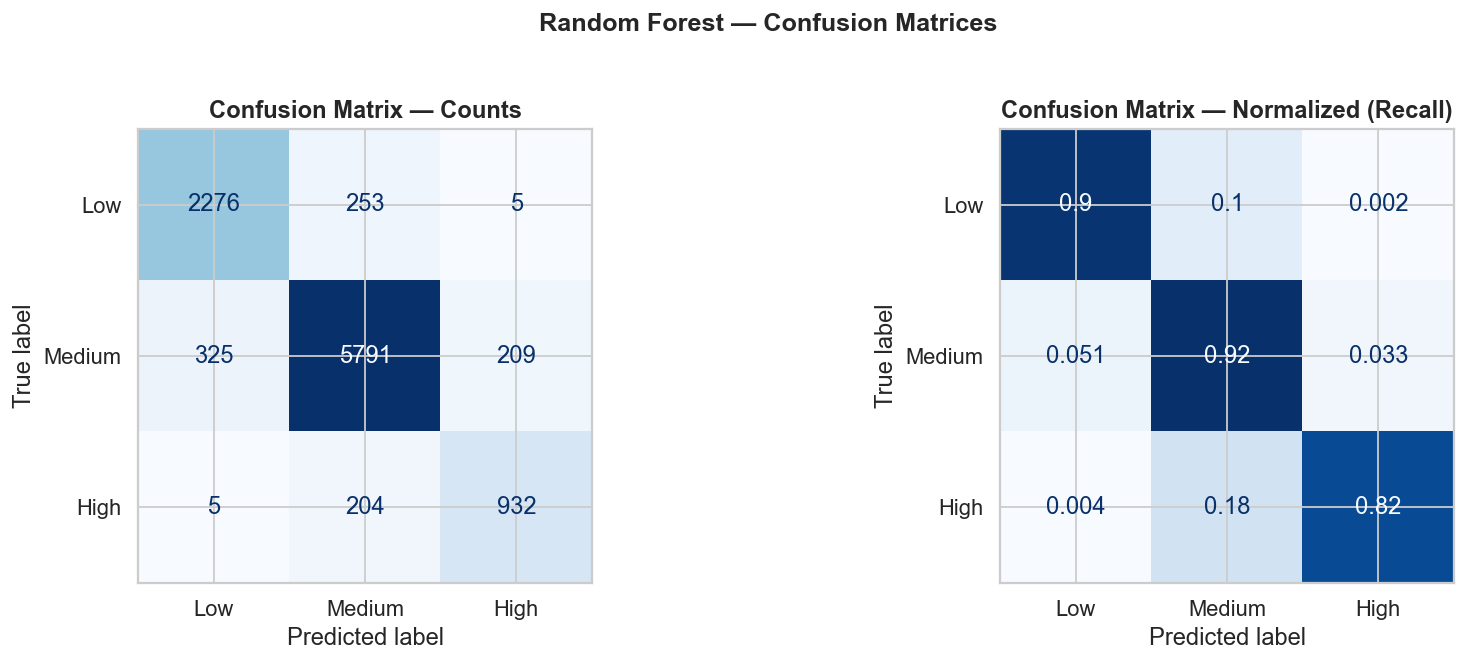

In [14]:
# Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Counts', fontweight='bold')

# Normalized (row-wise recall)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm.round(3), display_labels=['Low', 'Medium', 'High']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix — Normalized (Recall)', fontweight='bold')

plt.suptitle('Random Forest — Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

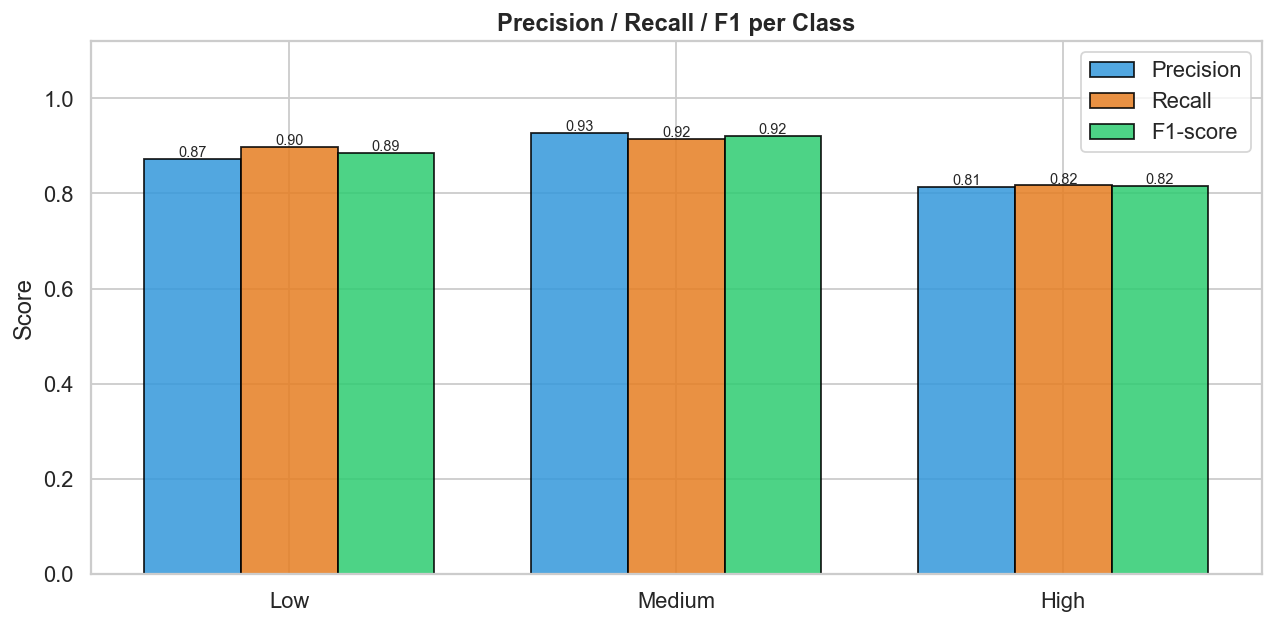

In [15]:
# Per-Class Metric Bar Chart 
report = classification_report(
    y_test, y_pred,
    target_names=['Low', 'Medium', 'High'],
    output_dict=True
)

classes    = ['Low', 'Medium', 'High']
metrics    = ['precision', 'recall', 'f1-score']
bar_colors = ['#3498db', '#e67e22', '#2ecc71']
x          = np.arange(len(classes))
width      = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    vals = [report[c][metric] for c in classes]
    bars = ax.bar(x + i*width, vals, width, label=metric.capitalize(),
                  color=color, edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 per Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

=== 5-Fold Stratified Cross-Validation ===

  Fold     Balanced Acc   Macro F1
  ───────────────────────────────────
  Fold 1         87.75%      0.8789
  Fold 2         86.90%      0.8687
  Fold 3         87.22%      0.8726
  Fold 4         87.27%      0.8734
  Fold 5         88.17%      0.8784
  ───────────────────────────────────
  Mean          87.46%      0.8744
  Std            0.44%      0.0038



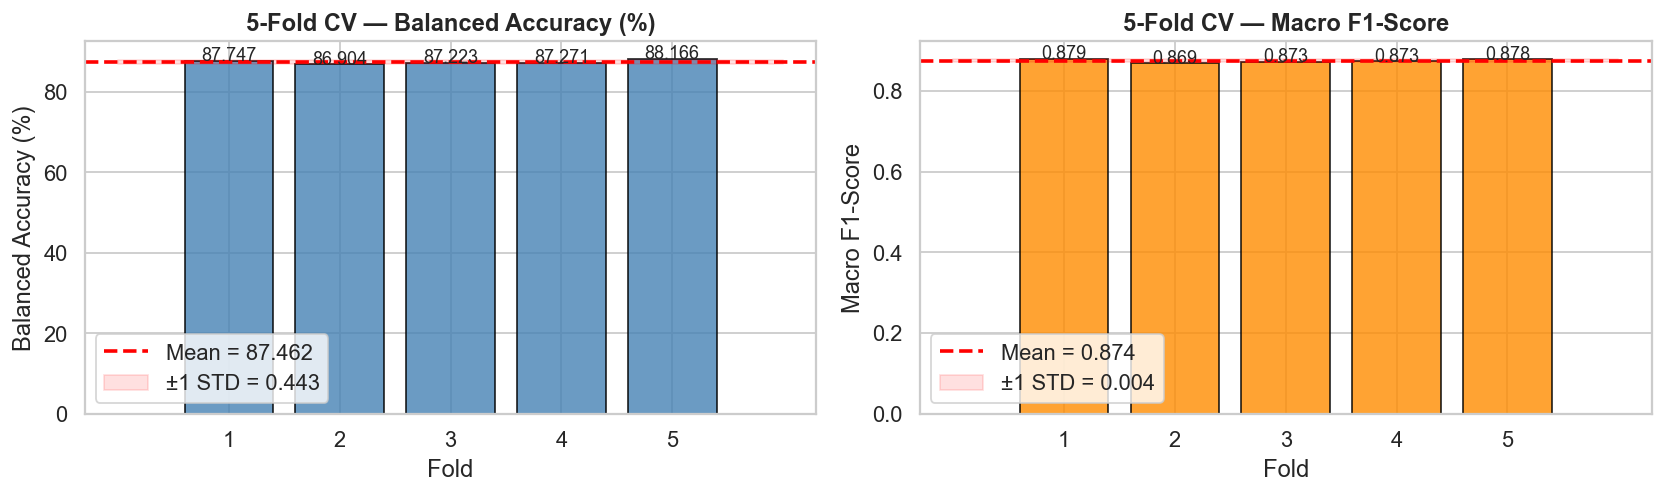

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Balanced Accuracy
cv_bal = cross_val_score(rf_model, X, y, cv=skf,
                         scoring='balanced_accuracy', n_jobs=-1)
# Macro F1
cv_f1  = cross_val_score(rf_model, X, y, cv=skf,
                         scoring='f1_macro', n_jobs=-1)

print('=== 5-Fold Stratified Cross-Validation ===')
print()
print(f'  {"Fold":<6} {"Balanced Acc":>14} {"Macro F1":>10}')
print('  ' + '─' * 35)
for i, (b, f) in enumerate(zip(cv_bal, cv_f1), 1):
    print(f'  Fold {i}  {b*100:>12.2f}%  {f:>10.4f}')
print('  ' + '─' * 35)
print(f'  Mean   {cv_bal.mean()*100:>12.2f}%  {cv_f1.mean():>10.4f}')
print(f'  Std    {cv_bal.std()*100:>12.2f}%  {cv_f1.std():>10.4f}')
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, scores, title, color in zip(
        axes,
        [cv_bal*100, cv_f1],
        ['Balanced Accuracy (%)', 'Macro F1-Score'],
        ['steelblue', 'darkorange']):

    bars = ax.bar(range(1, 6), scores, color=color, alpha=0.8, edgecolor='black')
    ax.axhline(scores.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {scores.mean():.3f}')
    ax.fill_between(range(0, 7), scores.mean()-scores.std(), scores.mean()+scores.std(),
                    alpha=0.12, color='red', label=f'±1 STD = {scores.std():.3f}')
    ax.set_title(f'5-Fold CV — {title}', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_xticks(range(1, 6))
    ax.legend()
    for i, v in enumerate(scores):
        ax.text(i+1, v + scores.std()*0.05, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

=== Top 15 Most Important Features ===
           Feature  Importance
     patient_count    0.171133
  avg_waiting_time    0.140805
     wait_pressure    0.126860
      bed_pressure    0.094939
  max_waiting_time    0.093211
       acuity_load    0.056549
    beds_available    0.054000
      staff_burden    0.031393
              hour    0.030632
     flow_pressure    0.026011
staff_burden_ratio    0.023220
      arrival_rate    0.022061
       day_of_week    0.019443
        is_weekend    0.016794
       temperature    0.015180


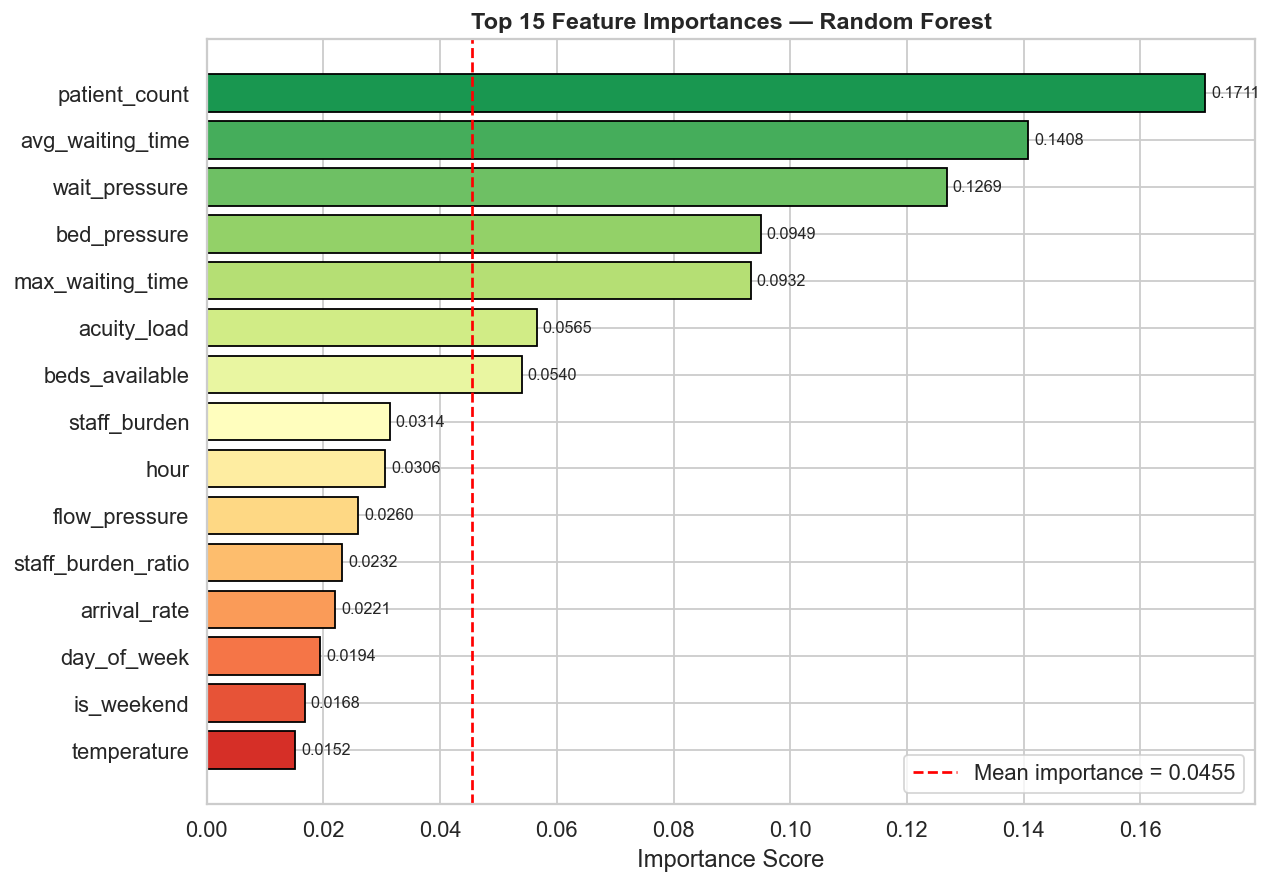

In [17]:
fi = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== Top 15 Most Important Features ===')
print(fi.head(15).to_string(index=False))

top15 = fi.head(15)
cmap  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 15))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1],
               color=cmap[::-1], edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.axvline(fi['Importance'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean importance = {fi["Importance"].mean():.4f}')
ax.legend()
plt.tight_layout()
plt.show()

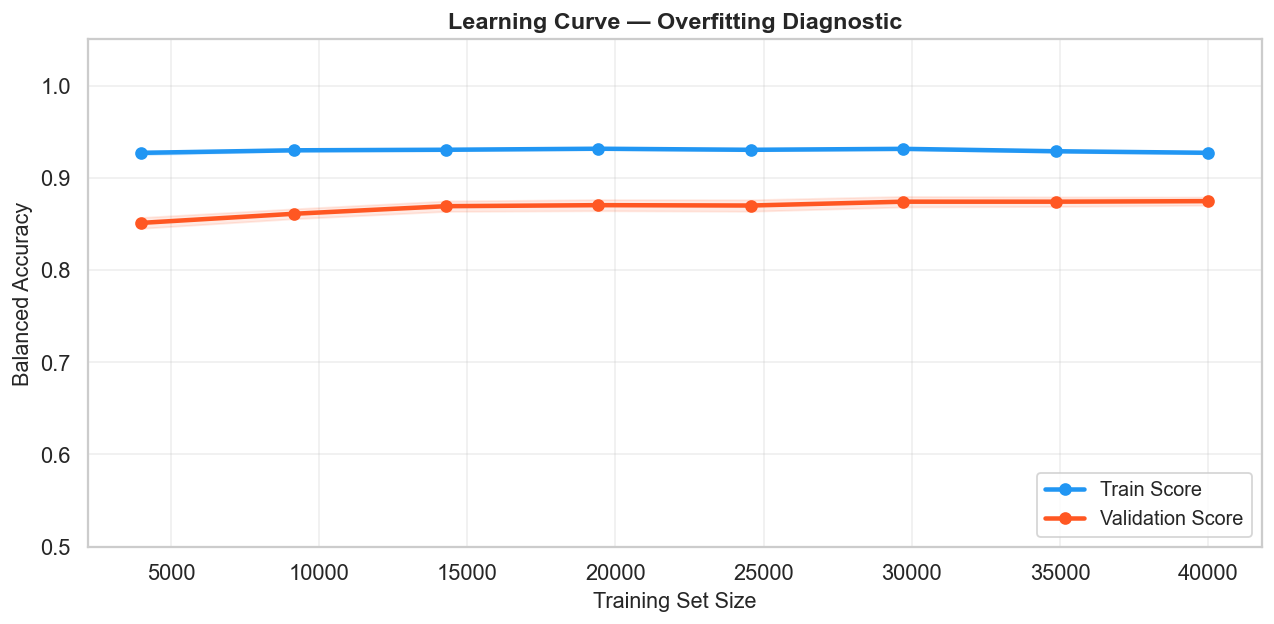

Final Train Score  : 0.9271
Final Val Score    : 0.8746
Gap                : 0.0524  →    Slight overfitting — acceptable for clinical setting


In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='#2196F3', linewidth=2.5, label='Train Score')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.12, color='#2196F3')
ax.plot(train_sizes, vl_mean, 'o-', color='#FF5722', linewidth=2.5, label='Validation Score')
ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.12, color='#FF5722')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.set_title('Learning Curve — Overfitting Diagnostic', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_gap = tr_mean[-1] - vl_mean[-1]
print(f'Final Train Score  : {tr_mean[-1]:.4f}')
print(f'Final Val Score    : {vl_mean[-1]:.4f}')
print(f'Gap                : {final_gap:.4f}', end='  →  ')
if final_gap < 0.05:
    print(' Model generalizes well — no overfitting')
elif final_gap < 0.10:
    print('  Slight overfitting — acceptable for clinical setting')
else:
    print(' Overfitting — try reducing max_depth or increasing min_samples_leaf')

In [19]:
import os

# Save model
joblib.dump(rf_model, 'saeif_crowding_model.pkl')

# Save feature names list (needed for inference)
joblib.dump(list(X.columns), 'saeif_feature_names.pkl')

# Save class mapping
class_map = {0: 'Low', 1: 'Medium', 2: 'High'}
joblib.dump(class_map, 'saeif_class_map.pkl')

# Save median imputation values (needed to fill NaN at inference time)
joblib.dump(medians.to_dict(), 'saeif_medians.pkl')

print('Files saved:')
print('   → saeif_crowding_model.pkl')
print('   → saeif_feature_names.pkl')
print('   → saeif_class_map.pkl')
print('   → saeif_medians.pkl')

Files saved:
   → saeif_crowding_model.pkl
   → saeif_feature_names.pkl
   → saeif_class_map.pkl
   → saeif_medians.pkl


In [20]:
loaded_model    = joblib.load('saeif_crowding_model.pkl')
loaded_features = joblib.load('saeif_feature_names.pkl')
loaded_map      = joblib.load('saeif_class_map.pkl')

# Take one sample from test set
sample = X_test.iloc[[0]]
pred_enc  = loaded_model.predict(sample)[0]
pred_prob = loaded_model.predict_proba(sample)[0]

print(' Sample Prediction Verification ')
print(f'  Predicted Level     : {pred_enc} → {loaded_map[pred_enc]}')
print(f'  Actual Level        : {y_test.iloc[0]} → {loaded_map[y_test.iloc[0]]}')
print()
print('  Class Probabilities:')
for cls, prob in zip([0, 1, 2], pred_prob):
    bar = '█' * int(prob * 30)
    print(f'    {loaded_map[cls]:8s}  {prob*100:5.1f}%  {bar}')
print()
print(' Model loaded and prediction verified!')

 Sample Prediction Verification 
  Predicted Level     : 1 → Medium
  Actual Level        : 1 → Medium

  Class Probabilities:
    Low         7.3%  ██
    Medium     82.4%  ████████████████████████
    High       10.3%  ███

 Model loaded and prediction verified!
